## qDRIFT

In this notebook we demonstrate how the TOPP-HATT optimisation procedure can be used to reduce the untranspiled and transpiled circuit depth of qDRIFT Hamiltonian simulation circuits.

In [1]:
import rustworkx as rx
import matplotlib.pyplot as plt
import numpy as np
import json
from pathlib import Path
from qiskit import QuantumCircuit
import qiskit.qasm2
import ferrmion as fr
from ferrmion.optimize import bonsai_algorithm
import pickle
from qiskit.transpiler import CouplingMap
from qiskit import transpile

In [2]:
ROOT_SEED = 2026 # this seed controls all randomness in the notebook

In [3]:
# qDRIFT simlulation functions
# these functions are from the TN4QA package
# https://github.com/UCL-CCS/TN4QA

# current dependency conflicts prevent direct import
# this will be resolved in a future release of TN4QA

def exp_pauli_string_to_circ(
              pauli_string: str,
              rot_angle: float
        ) -> QuantumCircuit:
        qc = QuantumCircuit(len(pauli_string))

        if pauli_string == "I" * len(pauli_string):
                return qc

        for p_idx in range(len(pauli_string)):
                p = pauli_string[p_idx]
                if p == "X":
                        qc.h(p_idx)
                elif p == "Y":
                        qc.sdg(p_idx)
                        qc.h(p_idx)

        non_id_qubits = [
                p_idx for p_idx in range(len(pauli_string)) if pauli_string[p_idx] != "I"
        ]
        for non_id_idx in range(len(non_id_qubits) - 1):
                q1, q2 = non_id_qubits[non_id_idx], non_id_qubits[non_id_idx + 1]
                qc.cx(q1, q2)
        qc.rz(2 * rot_angle, non_id_qubits[-1])
        for non_id_idx in range(len(non_id_qubits) - 1):
                q1, q2 = non_id_qubits[non_id_idx], non_id_qubits[non_id_idx + 1]
                qc.cx(q1, q2)

        for p_idx in range(len(pauli_string)):
                p = pauli_string[p_idx]
                if p == "X":
                        qc.h(p_idx)
                elif p == "Y":
                        qc.h(p_idx)
                        qc.s(p_idx)
        return qc

def QDriftSimulation(
              ham: dict[str, float], 
              duration: float, 
              error: float | None = None,
              seed: int | None = None
        ) -> QuantumCircuit:
        
        norm = np.sum([np.abs(x) for x in ham.values()])
        
        if error is None:
            error = 1e-3
        
        num_terms = int(np.ceil(2 * (norm**2) * (duration**2) / error))
        
        pauli_strings = list(ham.keys())
        num_qubits = len(pauli_strings[0])
        qc = QuantumCircuit(num_qubits)

        term_idxs = list(range(len(list(ham.keys()))))
        probs = [np.abs(weight) / norm for weight in ham.values()]
        rng = np.random.default_rng(seed)
        for _ in range(num_terms):
                sample = rng.choice(term_idxs, p=probs)
                p = list(ham.keys())[sample]
                sign = 1 if ham[p] >= 0.0 else -1
                temp_qc = exp_pauli_string_to_circ(p, norm * duration * sign / num_terms)
                qc.compose(temp_qc, inplace=True)

        return qc


In [4]:
def make_ham_real(hamiltonian: dict[str, complex]) -> dict[str, float]:
    real_ham = {}
    for item in hamiltonian:
        real_ham[item] = np.real(hamiltonian[item])
    return {k : v for k, v in sorted(real_ham.items(), key=lambda item: (item[1], item[0]))}

In [5]:
folder = Path.cwd().joinpath(Path("../../../python/tests/data/"))

with open(folder.joinpath("h2o_sto-3g.json"), 'r') as file:
    data = json.load(file)

ones = np.array(data["ones"])
twos = np.array(data["twos"])
enuc = data["constant_energy"]

In [6]:
# garnet_edges = [
#     (1, 0),
#     (1, 4),
#     (3, 0),
#     (3, 2),
#     (3, 4),
#     (3, 8),
#     (5, 4),
#     (5, 6),
#     (5, 10),
#     (7, 2),
#     (7, 8),
#     (7, 12),
#     (9, 4),
#     (9, 8),
#     (9, 10),
#     (9, 14),
#     (11, 6),
#     (11, 10),
#     (11, 16),
#     (13, 8),
#     (13, 12),
#     (13, 14),
#     (13, 17),
#     (15, 10),
#     (15, 14),
#     (15, 16),
#     (15, 19),
#     (18, 14),
#     (18, 17),
#     (18, 19)
# ]

In [7]:
with open("iqm_garnet_config.pkl", "rb") as f:
    iqm_garnet_config = pickle.load(f)

coupling_map = CouplingMap(iqm_garnet_config["coupling_map"])

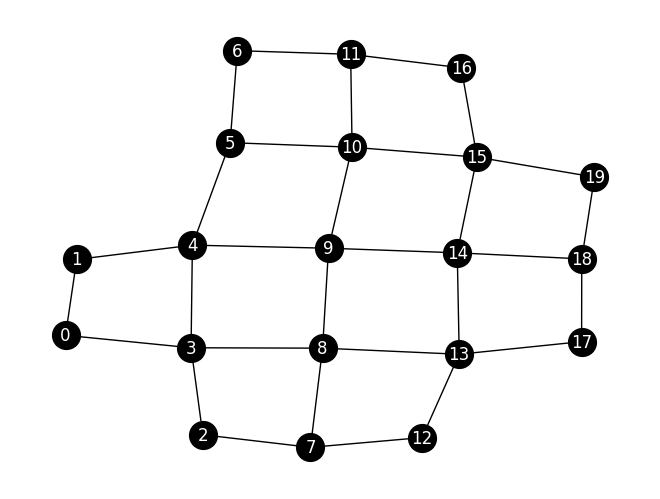

In [8]:
#rustworkx graph from edges (the actual input for bonsai)

garnet_graph_rx = rx.PyGraph()
num_qubits = max(max(pair) for pair in coupling_map) + 1
garnet_graph_rx.add_nodes_from(range(num_qubits))
garnet_graph_rx.add_edges_from_no_data(coupling_map)

rx.visualization.mpl_draw(
    graph = garnet_graph_rx, 
    with_labels = True,
    node_color = 'black',
    node_size = 400,
    font_color = 'white',
    pos = rx.spring_layout(garnet_graph_rx, seed=5)
)

In [9]:
n_modes = ones.shape[0]
n_modes

14

In [10]:
bonsai_garnet_truncated = bonsai_algorithm(
    graph = garnet_graph_rx,
    homogenous = False,
    max_nodes = n_modes
)

In [11]:
bonsai_garnet_truncated.n_qubits

20

In [12]:
def get_hams(name, tree, ones, twos, enuc):
    n_modes = ones.shape[0]

    if name in ["Jordan-Wigner", "Parity", "Bravyi-Kitaev", "JKMN", "JW", "BK", "PE"]:
        ham = fr.core.encode_standard(
            encoding=name,
            n_modes=n_modes,
            n_qubits=n_modes, # for standard we assume n_qubits = n_modes
            signatures=["+-","++--"],
            coeffs=[ones, twos],
            constant_energy=enuc,
        )
        
        ham = make_ham_real(ham)
        
        ipow,sym = fr.core.topphatt_standard(
            encoding=name,
            n_modes=n_modes,
            n_qubits=n_modes,
            signatures=["+-","++--"],
            coeffs=[ones, twos]
        )
    
    else:
        fermion_hamiltonian = fr.molecular_hamiltonian(
            one_e_coeffs=ones, 
            two_e_coeffs=twos, 
            constant_energy=enuc
        )
        
        ham = tree.encode(fermion_hamiltonian)
        ham = make_ham_real(ham)

        ipow,sym = fr.core.topphatt(
            flatpack=tree.flatpack(),
            n_qubits=tree.n_qubits,
            signatures=["+-","++--"], 
            coeffs=[ones, twos]
        )

    # build topphatt ham from ipowers and symplectics
    ham_topphatt = fr.core.encode(
        ipowers=ipow,
        symplectics=sym,
        signatures=["+-","++--"],
        coeffs=[ones, twos],
        constant_energy=enuc
    )
    ham_topphatt = make_ham_real(ham_topphatt)
    return (ham, ham_topphatt)

In [13]:
jw_hams = get_hams(
    name="Jordan-Wigner",
    tree=None,
    ones=ones,
    twos=twos,
    enuc=enuc
)

bk_hams = get_hams(
    name="Bravyi-Kitaev",
    tree=None,
    ones=ones,
    twos=twos,
    enuc=enuc
)

parity_hams = get_hams(
    name="Parity",
    tree=None,
    ones=ones,
    twos=twos,
    enuc=enuc
)

jkmn_hams = get_hams(
    name="JKMN",
    tree=None,
    ones=ones,
    twos=twos,
    enuc=enuc
)

bonsai_hams = get_hams(
    name=None,
    tree=bonsai_garnet_truncated,
    ones=ones,
    twos=twos,
    enuc=enuc
)

In [14]:
untranspiled_results = {
    "bonsai" : {
        "hams" : bonsai_hams,  
        "naive" : [], 
        "topphatt" : [], 
        "naive_mean_depth" : 0,
        "naive_mean_qasm" : "",
        "topphatt_mean_depth" : 0,
        "topphatt_mean_qasm" : "",
    },
    "JW" : {
        "hams" : jw_hams,  
        "naive" : [], 
        "topphatt" : [], 
        "naive_mean_depth" : 0,
        "naive_mean_qasm" : "",
        "topphatt_mean_depth" : 0,
        "topphatt_mean_qasm" : "",
    },
    "BK" : {
        "hams" : bk_hams,  
        "naive" : [], 
        "topphatt" : [], 
        "naive_mean_depth" : 0,
        "naive_mean_qasm" : "",
        "topphatt_mean_depth" : 0,
        "topphatt_mean_qasm" : "",
    },
    "parity" : {
        "hams" : parity_hams,  
        "naive" : [], 
        "topphatt" : [], 
        "naive_mean_depth" : 0,
        "naive_mean_qasm" : "",
        "topphatt_mean_depth" : 0,
        "topphatt_mean_qasm" : "",
    },
    "JKMN" : {
        "hams" : jkmn_hams,  
        "naive" : [], 
        "topphatt" : [], 
        "naive_mean_depth" : 0,
        "naive_mean_qasm" : "",
        "topphatt_mean_depth" : 0,
        "topphatt_mean_qasm" : "",
    },
}

In [15]:
def run_qdrift(hams, duration, root_seed, trial):
    seed = None if root_seed is None else root_seed + trial
    qdrift = QDriftSimulation(
        ham = hams[0],
        duration = duration,
        error = 1e-3,
        seed = seed
    )
    naive_depth = qdrift.depth()

    qdrift = QDriftSimulation(
        ham = hams[1],
        duration = duration,
        error = 1e-3,
        seed = seed
    )
    tophatt_depth = qdrift.depth()

    return (naive_depth, tophatt_depth)

In [16]:
# test seed:

naive_depth, tophatt_depth = run_qdrift(jw_hams, 0.001, root_seed=ROOT_SEED, trial=0)
print(naive_depth, tophatt_depth)

naive_depth, tophatt_depth = run_qdrift(jw_hams, 0.001, root_seed=ROOT_SEED, trial=0)
print(naive_depth, tophatt_depth)

53 33
53 33


In [17]:
dur = 0.001
repeats = 1000

for trial in range(repeats):
    for encoding, data in untranspiled_results.items():
        naive_depth, tophatt_depth = run_qdrift(
            hams=data["hams"],
            duration=dur,
            root_seed=ROOT_SEED,
            trial=trial
        )
        data["naive"].append(naive_depth)
        data["topphatt"].append(tophatt_depth)

In [18]:
# with open("untranspiled_results.json", 'w') as f:
#     json.dump(results, f)

In [19]:
# with open("untranspiled_results.json", 'r') as f:
#     results = json.load(f)

JW
naive 1000
35.1 12.3
TOPP-HATT 1000
28.2 10.4
reduction
19.6 41.0

parity
naive 1000
49.3 12.7
TOPP-HATT 1000
40.6 10.5
reduction
17.7 30.1

BK
naive 1000
63.4 14.0
TOPP-HATT 1000
35.7 11.5
reduction
43.7 21.9

JKMN
naive 1000
58.0 13.1
TOPP-HATT 1000
43.1 12.5
reduction
25.7 27.3

bonsai
naive 1000
63.3 15.2
TOPP-HATT 1000
51.5 13.9
reduction
18.6 29.3


25.1, 9.7


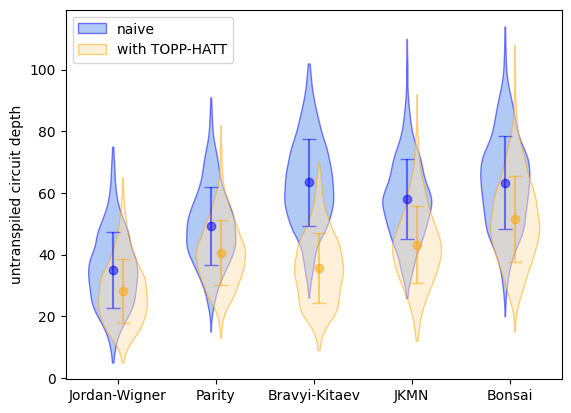

In [20]:
order = ["JW", "parity", "BK", "JKMN", "bonsai"]
names = ["Jordan-Wigner", "Parity", "Bravyi-Kitaev", "JKMN", "Bonsai"]

spacing = 0.05

naive_data   = [untranspiled_results[name]["naive"] for name in order]
tophatt_data = [untranspiled_results[name]["topphatt"]    for name in order]

positions_naive   = [i + 1 - spacing for i in range(len(order))]
positions_tophatt = [i + 1 + spacing for i in range(len(order))]

plt.tight_layout()

naive_violin = plt.violinplot(
    dataset=naive_data,
    positions=positions_naive,
)
tophatt_violin = plt.violinplot(
    dataset=tophatt_data,
    positions=positions_tophatt,
)

alpha = 0.5
naive_edge = 'blue'
naive_fill = 'cornflowerblue'
tophatt_edge = 'orange'
tophatt_fill = 'moccasin'

for i, body in enumerate(naive_violin['bodies']):
    body.set_facecolor(naive_fill)
    body.set_edgecolor(naive_edge)
    body.set_alpha(alpha)

naive_violin['bodies'][0].set_label("naive")

for i, body in enumerate(tophatt_violin['bodies']):
    body.set_facecolor(tophatt_fill)
    body.set_edgecolor(tophatt_edge)
    body.set_alpha(alpha)

tophatt_violin['bodies'][0].set_label("with TOPP-HATT")


for key in ["cbars", "cmaxes", "cmins"]:
    naive_violin[key].set_color("none")
    tophatt_violin[key].set_color("none")

reductions = []

for i, encoding in enumerate(order):
    x_naive = positions_naive[i]
    x_topphatt = positions_tophatt[i]

    y_naive = np.mean(untranspiled_results[encoding]["naive"])
    e_naive = np.std(untranspiled_results[encoding]["naive"])

    y_topphatt = np.mean(untranspiled_results[encoding]["topphatt"])
    e_topphatt = np.std(untranspiled_results[encoding]["topphatt"])

    plt.errorbar(x=x_naive, y=y_naive,
                 yerr=e_naive, fmt='o', color=naive_edge,
                 capsize=5, alpha=alpha)

    plt.errorbar(x=x_topphatt, y=y_topphatt,
                 yerr=e_topphatt, fmt='o', color=tophatt_edge,
                 capsize=5, alpha=alpha)
    
    reductions.append(100*(1 - y_topphatt/y_naive))
    
    print(encoding)
    print('naive', len(untranspiled_results[encoding]["naive"]))
    print(f'{y_naive:.1f}', f'{e_naive:.1f}')
    print('TOPP-HATT', len(untranspiled_results[encoding]["topphatt"]))
    print(f'{y_topphatt:.1f}', f'{e_topphatt:.1f}')
    print('reduction')
    print(f'{100*(1 - y_topphatt/y_naive):.1f}', f'{100*np.sqrt((y_topphatt**2 * e_naive**2)/(y_naive**4) + (e_topphatt**2)/(y_naive**2)):.1f}')
    print()

print()
print(f'{np.mean(reductions):.1f}, {np.std(reductions):.1f}')

plt.legend(loc="upper left")
plt.xticks([i + 1 for i in range(len(order))], names)
plt.ylabel("untranspiled circuit depth")

plt.savefig("untranspiled_qdrift.pdf")

plt.show()

In [21]:
for encoding in untranspiled_results.keys():
    data = untranspiled_results[encoding]
    hams = data["hams"]

    for variant, ham in zip(["naive", "topphatt"], hams):
        
        target_depth = int(np.mean(data[variant]))

        trial = 0

        while True:
            seed = ROOT_SEED + trial
            qdrift = qdrift = QDriftSimulation(
                ham = ham,
                duration = dur,
                error = 1e-3,
                seed = seed
            )
            trial += 1

            if qdrift.depth() == target_depth:
                untranspiled_results[encoding][f"{variant}_mean_depth"] = target_depth
                untranspiled_results[encoding][f"{variant}_mean_qasm"] = qiskit.qasm2.dumps(qdrift)
                print(f"done {encoding} {variant} {target_depth}")
                break

done bonsai naive 63
done bonsai topphatt 51
done JW naive 35
done JW topphatt 28
done BK naive 63
done BK topphatt 35
done parity naive 49
done parity topphatt 40
done JKMN naive 58
done JKMN topphatt 43


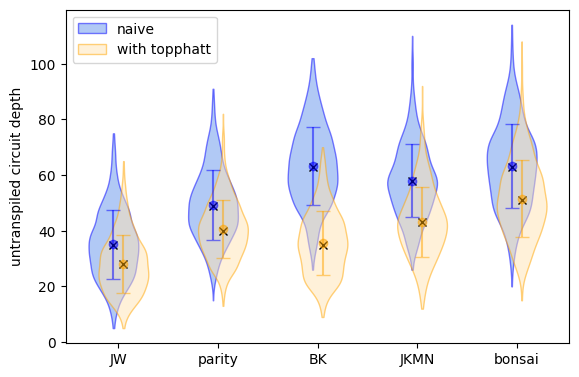

In [22]:
spacing = 0.05

naive_data   = [untranspiled_results[name]["naive"] for name in order]
tophatt_data = [untranspiled_results[name]["topphatt"]    for name in order]

positions_naive   = [i + 1 - spacing for i in range(len(order))]
positions_tophatt = [i + 1 + spacing for i in range(len(order))]

plt.figure(figsize=(468/72, (468*(2/3))/72))
plt.tight_layout()

naive_violin = plt.violinplot(
    dataset=naive_data,
    positions=positions_naive,
)
tophatt_violin = plt.violinplot(
    dataset=tophatt_data,
    positions=positions_tophatt,
)

alpha = 0.5
naive_edge = 'blue'
naive_fill = 'cornflowerblue'
tophatt_edge = 'orange'
tophatt_fill = 'moccasin'

for i, body in enumerate(naive_violin['bodies']):
    body.set_facecolor(naive_fill)
    body.set_edgecolor(naive_edge)
    body.set_alpha(alpha)

naive_violin['bodies'][0].set_label("naive")

for i, body in enumerate(tophatt_violin['bodies']):
    body.set_facecolor(tophatt_fill)
    body.set_edgecolor(tophatt_edge)
    body.set_alpha(alpha)

tophatt_violin['bodies'][0].set_label("with topphatt")


for key in ["cbars", "cmaxes", "cmins"]:
    naive_violin[key].set_color("none")
    tophatt_violin[key].set_color("none")

for i, name in enumerate(order):
    x_naive = positions_naive[i]
    x_topphatt = positions_tophatt[i]

    y_naive = np.mean(untranspiled_results[name]["naive"])
    e_naive = np.std(untranspiled_results[name]["naive"])

    y_topphatt = np.mean(untranspiled_results[name]["topphatt"])
    e_topphatt = np.std(untranspiled_results[name]["topphatt"])

    depth_naive = untranspiled_results[name]["naive_mean_depth"]
    depth_topphatt = untranspiled_results[name]["topphatt_mean_depth"]

    plt.errorbar(x=x_naive, y=y_naive,
                 yerr=e_naive, fmt='o', color=naive_edge,
                 capsize=5, alpha=alpha)

    plt.errorbar(x=x_topphatt, y=y_topphatt,
                 yerr=e_topphatt, fmt='o', color=tophatt_edge,
                 capsize=5, alpha=alpha)
    
    plt.plot(x_naive, depth_naive, 'x', color='black')
    plt.plot(x_topphatt, depth_topphatt, 'x', color='black')

plt.legend(loc="upper left")
plt.xticks([i + 1 for i in range(len(order))], order)
plt.ylabel("untranspiled circuit depth")

plt.show()

In [23]:
# with open("untranspiled_results.json", 'w') as f:
#     json.dump(results, f, indent=4)

## now we will transpile these circuits

We can load in a QPU backend for transpilation with the Qiskit transpiler. We will use the IQM Garnet 20-qubit device. 

In [24]:
coupling_map = CouplingMap(iqm_garnet_config["coupling_map"])
basis_gates = iqm_garnet_config["basis_gates"]

In [25]:
def transpile_for_iqm(
        circuit,
        coupling_map,
        basis_gates,
        optim_level,
        root_seed=None,
        trial=None,
    ):
    seed = None if root_seed is None else root_seed + trial
    return transpile(
        circuit,
        basis_gates=basis_gates,
        coupling_map=coupling_map,
        optimization_level=optim_level,
        seed_transpiler=seed,
    )

In [26]:
transpiled_results = {
    "bonsai":   {"naive": [], "topphatt": []},
    "JW":       {"naive": [], "topphatt": []},
    "BK":       {"naive": [], "topphatt": []},
    "parity":   {"naive": [], "topphatt": []},
    "JKMN":     {"naive": [], "topphatt": []},
}

In [27]:
# with open("untranspiled_results.json", 'r') as infile:
#     untranspiled_results = json.load(infile)

In [28]:
optim_level = 3
repeats = 100

for encoding in untranspiled_results.keys():
    for variant in ['naive', 'topphatt']:
        qasm_string = untranspiled_results[encoding][f"{variant}_mean_qasm"]
        qc = qiskit.qasm2.loads(qasm_string)
        for i in range(repeats):
            qc_transpiled = transpile_for_iqm(
                circuit=qc,
                coupling_map=coupling_map,
                basis_gates=basis_gates,
                optim_level=optim_level,
                root_seed=ROOT_SEED,
                trial=i,
            )
            transpiled_results[encoding][variant].append(qc_transpiled.depth())

In [29]:
# with open("transpiled_results.json", 'w') as f:
#     json.dump(results, f, indent=4)

In [30]:
# with open("transpiled_results.json", 'r') as f:
#     results = json.load(f)

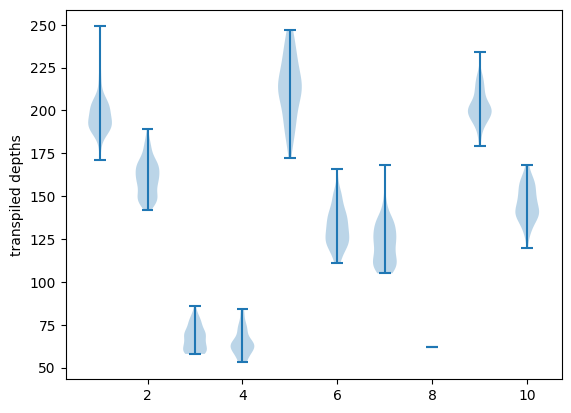

In [31]:
plt.violinplot([
    transpiled_results["bonsai"]["naive"],
    transpiled_results["bonsai"]["topphatt"],
    transpiled_results["JW"]["naive"],
    transpiled_results["JW"]["topphatt"],
    transpiled_results["BK"]["naive"],
    transpiled_results["BK"]["topphatt"],
    transpiled_results["parity"]["naive"],
    transpiled_results["parity"]["topphatt"],
    transpiled_results["JKMN"]["naive"],
    transpiled_results["JKMN"]["topphatt"],
])

plt.ylabel('transpiled depths')

plt.show()

JW
naive 100
67.4 7.2
TOPP-HATT 100
64.8 7.7
reduction
3.8 15.4

parity
naive 100
123.3 12.9
TOPP-HATT 100
62.0 0.0
reduction
49.7 5.3

BK
naive 100
213.2 17.8
TOPP-HATT 100
132.0 11.6
reduction
38.1 7.5

JKMN
naive 100
202.4 9.8
TOPP-HATT 100
145.8 10.5
reduction
28.0 6.2

bonsai
naive 100
197.6 11.4
TOPP-HATT 100
160.9 10.6
reduction
18.6 7.1


27.6, 15.8


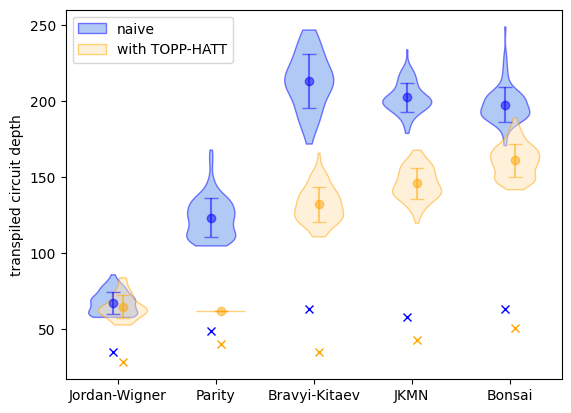

In [32]:
order = ["JW", "parity", "BK", "JKMN", "bonsai"]
names = ["Jordan-Wigner", "Parity", "Bravyi-Kitaev", "JKMN", "Bonsai"]

spacing = 0.05

naive_data   = [transpiled_results[name]["naive"] for name in order]
tophatt_data = [transpiled_results[name]["topphatt"]    for name in order]

positions_naive   = [i + 1 - spacing for i in range(len(order))]
positions_tophatt = [i + 1 + spacing for i in range(len(order))]

plt.tight_layout()

naive_violin = plt.violinplot(
    dataset=naive_data,
    positions=positions_naive,
)
tophatt_violin = plt.violinplot(
    dataset=tophatt_data,
    positions=positions_tophatt,
)

alpha = 0.5
naive_edge = 'blue'
naive_fill = 'cornflowerblue'
tophatt_edge = 'orange'
tophatt_fill = 'moccasin'

for i, body in enumerate(naive_violin['bodies']):
    body.set_facecolor(naive_fill)
    body.set_edgecolor(naive_edge)
    body.set_alpha(alpha)

naive_violin['bodies'][0].set_label("naive")

for i, body in enumerate(tophatt_violin['bodies']):
    body.set_facecolor(tophatt_fill)
    body.set_edgecolor(tophatt_edge)
    body.set_alpha(alpha)

tophatt_violin['bodies'][0].set_label("with TOPP-HATT")

for key in ["cbars", "cmaxes", "cmins"]:
    naive_violin[key].set_color("none")
    tophatt_violin[key].set_color("none")

reductions = []

for i, encoding in enumerate(order):
    x_naive = positions_naive[i]
    x_topphatt = positions_tophatt[i]

    y_naive = np.mean(transpiled_results[encoding]["naive"])
    e_naive = np.std(transpiled_results[encoding]["naive"])

    y_topphatt = np.mean(transpiled_results[encoding]["topphatt"])
    e_topphatt = np.std(transpiled_results[encoding]["topphatt"])

    plt.errorbar(x=x_naive, y=y_naive,
                 yerr=e_naive, fmt='o', color=naive_edge,
                 capsize=5, alpha=alpha)

    plt.errorbar(x=x_topphatt, y=y_topphatt,
                 yerr=e_topphatt, fmt='o', color=tophatt_edge,
                 capsize=5, alpha=alpha)
    
    naive_depth = untranspiled_results[encoding]["naive_mean_depth"]
    tophatt_depth = untranspiled_results[encoding]["topphatt_mean_depth"]

    plt.plot(x_naive, naive_depth, 'x', color=naive_edge)
    plt.plot(x_topphatt, tophatt_depth, 'x', color=tophatt_edge)

    reductions.append(100*(1 - y_topphatt/y_naive))
    
    print(encoding)
    print('naive', len(transpiled_results[encoding]["naive"]))
    print(f'{y_naive:.1f}', f'{e_naive:.1f}')
    print('TOPP-HATT', len(transpiled_results[encoding]["topphatt"]))
    print(f'{y_topphatt:.1f}', f'{e_topphatt:.1f}')
    print('reduction')
    print(f'{100*(1 - y_topphatt/y_naive):.1f}', f'{100*np.sqrt((y_topphatt**2 * e_naive**2)/(y_naive**4) + (e_topphatt**2)/(y_naive**2)):.1f}')
    print()

print()
print(f'{np.mean(reductions):.1f}, {np.std(reductions):.1f}')

plt.legend(loc="upper left")
plt.xticks([i + 1 for i in range(len(order))], names)
plt.ylabel("transpiled circuit depth")

plt.savefig("transpiled_qdrift.pdf")

plt.show()

# water with different qDRIFT durations

In [33]:
def pauli_weights(pauli_hamiltonian: dict[str, float]) -> list[float]:
    unscaled_terms = []
    scaled_terms = []
    for k, v in pauli_hamiltonian.items():
        assert v != 0
        pw = (len(k) - k.count("I")) 
        unscaled_terms.append(pw)
        scaled_terms.append(pw* np.abs(v))

    return (unscaled_terms, scaled_terms, len(pauli_hamiltonian))

In [34]:
durations = np.arange(0.001, 0.011, 0.0005)
durations

array([0.001 , 0.0015, 0.002 , 0.0025, 0.003 , 0.0035, 0.004 , 0.0045,
       0.005 , 0.0055, 0.006 , 0.0065, 0.007 , 0.0075, 0.008 , 0.0085,
       0.009 , 0.0095, 0.01  , 0.0105])

In [35]:
duration_scan_results = {str(i) : {"JW" : [], "TH" : []} for i, _ in enumerate(durations)}

In [36]:
duration_scan_results

{'0': {'JW': [], 'TH': []},
 '1': {'JW': [], 'TH': []},
 '2': {'JW': [], 'TH': []},
 '3': {'JW': [], 'TH': []},
 '4': {'JW': [], 'TH': []},
 '5': {'JW': [], 'TH': []},
 '6': {'JW': [], 'TH': []},
 '7': {'JW': [], 'TH': []},
 '8': {'JW': [], 'TH': []},
 '9': {'JW': [], 'TH': []},
 '10': {'JW': [], 'TH': []},
 '11': {'JW': [], 'TH': []},
 '12': {'JW': [], 'TH': []},
 '13': {'JW': [], 'TH': []},
 '14': {'JW': [], 'TH': []},
 '15': {'JW': [], 'TH': []},
 '16': {'JW': [], 'TH': []},
 '17': {'JW': [], 'TH': []},
 '18': {'JW': [], 'TH': []},
 '19': {'JW': [], 'TH': []}}

In [37]:
repeats = 10

for i in range(repeats):
    for j, duration in enumerate(durations):
        naive_depth, tophatt_depth = run_qdrift(
            hams = jw_hams,
            duration = duration,
            root_seed = ROOT_SEED,
            trial = i
        )
        
        duration_scan_results[str(j)]["JW"].append(naive_depth)
        duration_scan_results[str(j)]["TH"].append(tophatt_depth)

    print('done repeat', i + 1, 'of', repeats, end='\r')

In [38]:
duration_scan_results["durations"] = durations.tolist()

In [39]:
# with open("qdrift_depths_scan.json", 'w') as f:
#     json.dump(results, f, indent=4)

In [40]:
# with open("qdrift_depths_scan.json", 'r') as f:
#     results = json.load(f)

In [41]:
durations = duration_scan_results["durations"]

In [42]:
JW_mean_depths = []
JW_std_depths = []
TH_mean_depths = []
TH_std_depths = []

for i, _ in enumerate(durations):
    JW_mean_depths.append(np.mean(duration_scan_results[str(i)]["JW"]))
    JW_std_depths.append(np.std(duration_scan_results[str(i)]["JW"]))
    TH_mean_depths.append(np.mean(duration_scan_results[str(i)]["TH"]))
    TH_std_depths.append(np.std(duration_scan_results[str(i)]["TH"]))

In [43]:
reductions = []

for i, depth in enumerate(JW_mean_depths):
    reductions.append(100*(1 - TH_mean_depths[i]/depth))
    print(f'{durations[i]:.4f}', '&', f'{depth:.1f}', '&', f'{TH_mean_depths[i]:.1f}', '&',  f'{100*(1 - TH_mean_depths[i]/depth):.1f}')

print()
print(f'{np.mean(reductions):.1f}, {np.std(reductions):.1f}')

0.0010 & 39.6 & 32.2 & 18.7
0.0015 & 75.1 & 66.2 & 11.9
0.0020 & 130.6 & 109.2 & 16.4
0.0025 & 196.8 & 165.9 & 15.7
0.0030 & 279.5 & 233.7 & 16.4
0.0035 & 374.7 & 308.3 & 17.7
0.0040 & 478.6 & 395.7 & 17.3
0.0045 & 612.4 & 495.3 & 19.1
0.0050 & 754.1 & 611.5 & 18.9
0.0055 & 896.6 & 729.6 & 18.6
0.0060 & 1052.2 & 852.5 & 19.0
0.0065 & 1223.0 & 991.6 & 18.9
0.0070 & 1443.8 & 1165.2 & 19.3
0.0075 & 1642.9 & 1321.7 & 19.6
0.0080 & 1873.2 & 1513.1 & 19.2
0.0085 & 2106.9 & 1700.9 & 19.3
0.0090 & 2385.9 & 1916.3 & 19.7
0.0095 & 2653.3 & 2124.9 & 19.9
0.0100 & 2939.1 & 2363.8 & 19.6
0.0105 & 3244.6 & 2611.0 & 19.5

18.2, 1.9


In [44]:
JW_mean_depths = np.array(JW_mean_depths)
JW_std_depths = np.array(JW_std_depths)
TH_mean_depths = np.array(TH_mean_depths)
TH_std_depths = np.array(TH_std_depths)

In [45]:
from numpy.polynomial import Polynomial

In [46]:
JW_fit = Polynomial.fit(durations, JW_mean_depths, deg=2)
TH_fit = Polynomial.fit(durations, TH_mean_depths, deg=2)

In [47]:
print(JW_fit)
print()
print(TH_fit)

973.97852273 + 1595.27928571·(-1.21052632 + 210.52631579x) +
668.1661526·(-1.21052632 + 210.52631579x)²

789.8425 + 1279.45857143·(-1.21052632 + 210.52631579x) +
530.88035714·(-1.21052632 + 210.52631579x)²


In [48]:
JW_fit = Polynomial.fit(np.log(durations), np.log(JW_mean_depths), deg=1)
TH_fit = Polynomial.fit(np.log(durations), np.log(TH_mean_depths), deg=1)

In [49]:
print(JW_fit)
print()
print(TH_fit)

5.80750973 + 2.23873947·(4.87550223 + 0.85056607x)

5.61604147 + 2.20912403·(4.87550223 + 0.85056607x)


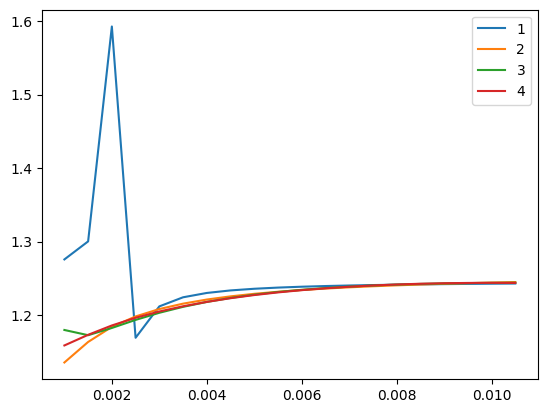

In [50]:
JW_fit = Polynomial.fit(durations, JW_mean_depths, deg=1)
TH_fit = Polynomial.fit(durations, TH_mean_depths, deg=1)
plt.plot(durations, JW_fit(durations)/TH_fit(durations), label='1')

JW_fit = Polynomial.fit(durations, JW_mean_depths, deg=2)
TH_fit = Polynomial.fit(durations, TH_mean_depths, deg=2)
plt.plot(durations, JW_fit(durations)/TH_fit(durations), label='2')

JW_fit = Polynomial.fit(durations, JW_mean_depths, deg=3)
TH_fit = Polynomial.fit(durations, TH_mean_depths, deg=3)
plt.plot(durations, JW_fit(durations)/TH_fit(durations), label='3')

JW_fit = Polynomial.fit(durations, JW_mean_depths, deg=4)
TH_fit = Polynomial.fit(durations, TH_mean_depths, deg=4)
plt.plot(durations, JW_fit(durations)/TH_fit(durations), label='4')
plt.legend()

plt.show()

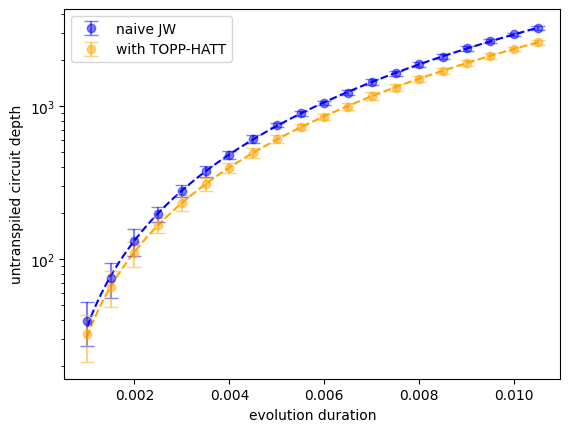

In [51]:
naive_edge = 'blue'
naive_fill = 'cornflowerblue'
tophatt_edge = 'orange'
tophatt_fill = 'moccasin'

plt.tight_layout()

durations_fine = np.linspace(min(durations), max(durations), 100)

plt.plot(durations_fine, JW_fit(durations_fine), '--', color=naive_edge)
plt.plot(durations_fine, TH_fit(durations_fine), '--', color=tophatt_edge)

plt.errorbar(
    durations,
    JW_mean_depths,
    yerr=JW_std_depths,
    fmt='o',
    color=naive_edge,
    capsize=5,
    alpha=0.5,
    label='naive JW'
)

plt.errorbar(
    durations,
    TH_mean_depths,
    yerr=TH_std_depths,
    fmt='o',
    color=tophatt_edge,
    capsize=5,
    alpha=0.5,
    label='with TOPP-HATT' 
)

plt.xlabel('evolution duration')
plt.ylabel('untranspiled circuit depth')

plt.yscale('log')

plt.legend()

plt.savefig("qdrift_depths_scan.pdf")

plt.show()